# AM01 AAE Warm-up Smooth L1 Experiment

Notebook sperimentale mirato all'ultima ablation AAE promettente: **Smooth L1 + warm-up ricostruttivo + ramp lineare della componente adversarial**.

Direzione testata: l'AAE potrebbe non migliorare AE perche' il latent space viene regolarizzato verso `N(0,I)` troppo presto, quando encoder e decoder non hanno ancora imparato una manifold normale stabile.

Questo notebook non modifica il protocollo ufficiale: salva tutto in una cartella separata e serve a decidere se il warm-up merita di entrare nel report finale.

## 0. Parametri

In [1]:
from pathlib import Path

REPO_URL = "https://github.com/Bernuz2003/AML_anomaliy_detection.git"  # opzionale: https://github.com/<user>/<repo>.git
PROJECT_DIR = Path('/content/am01-kuka-aae-anomaly-detection')
DRIVE_ROOT = Path('/content/drive/MyDrive/AM01')
DATA_DIR = DRIVE_ROOT / 'data' / 'KukaVelocityDataset'
RESULTS_ROOT = DRIVE_ROOT / 'results' / 'official' / 'warmup_aae_smoothl1'
TABLES_DIR = RESULTS_ROOT / 'tables'
FIGURES_DIR = RESULTS_ROOT / 'figures'
RUNS_DIR = RESULTS_ROOT / 'runs'
CONFIG_DIR = RESULTS_ROOT / 'config'

RUN_BASELINES = True
RUN_WARMUP_GRID = True
RUN_CONFIRMATION_MULTI_SEED = True

PRIMARY_WINDOW_LENGTH = 64
PRIMARY_STRIDE = 16
SEED_EXPLORATION = 42
CONFIRMATION_SEEDS = [0, 1, 2]
SELECTION_METRIC = 'val_pr_auc'

# Griglia minima: niente w128, niente tuning esteso.
WARMUP_CONFIGS = [
    {'name': 'aae_smoothl1_no_warmup', 'warmup_epochs': 0, 'ramp_epochs': 0, 'lambda_adv': 0.10},
    {'name': 'aae_smoothl1_warm5_ramp5_lam0p10', 'warmup_epochs': 5, 'ramp_epochs': 5, 'lambda_adv': 0.10},
    {'name': 'aae_smoothl1_warm10_ramp5_lam0p10', 'warmup_epochs': 10, 'ramp_epochs': 5, 'lambda_adv': 0.10},
    {'name': 'aae_smoothl1_warm10_ramp5_lam0p01', 'warmup_epochs': 10, 'ramp_epochs': 5, 'lambda_adv': 0.01},
    {'name': 'aae_smoothl1_warm10_ramp5_lam0p05', 'warmup_epochs': 10, 'ramp_epochs': 5, 'lambda_adv': 0.05},
]

print('DATA_DIR:', DATA_DIR)
print('RESULTS_ROOT:', RESULTS_ROOT)

DATA_DIR: /content/drive/MyDrive/AM01/data/KukaVelocityDataset
RESULTS_ROOT: /content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1


## 1. Setup Colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import subprocess
import sys


def sh(cmd: str) -> None:
    print(f"\n$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

for path in [RESULTS_ROOT, TABLES_DIR, FIGURES_DIR, RUNS_DIR, CONFIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if not PROJECT_DIR.exists():
    if not REPO_URL:
        raise RuntimeError('PROJECT_DIR non esiste. Imposta REPO_URL o carica il repo in /content.')
    sh(f'git clone {REPO_URL} "{PROJECT_DIR}"')

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))
print('Working directory:', Path.cwd())

sh('pip install -q -r requirements.txt')
sh('python -m compileall -q src scripts')
sh(f'pip freeze > "{CONFIG_DIR / "environment.txt"}"')


$ git clone https://github.com/Bernuz2003/AML_anomaliy_detection.git "/content/am01-kuka-aae-anomaly-detection"
Working directory: /content/am01-kuka-aae-anomaly-detection

$ pip install -q -r requirements.txt

$ python -m compileall -q src scripts

$ pip freeze > "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/config/environment.txt"


## 2. Import e utility

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

import am01.reporting as rpt

sns.set_theme(style='whitegrid', context='notebook')


def run_experiment_command(config, output, *, seed=42, loss='huber', lambda_adv=None, warmup=None, ramp=None, configs='configs/aae_mlp.yaml'):
    parts = [
        'python scripts/run_experiments.py',
        f'--configs {configs}',
        f'--data "{DATA_DIR}"',
        f'--output "{output}"',
        f'--seeds {seed}',
        f'--window-lengths {PRIMARY_WINDOW_LENGTH}',
        f'--losses {loss}',
        '--skip-existing',
        f'--summary-name {config}.csv',
    ]
    if lambda_adv is not None:
        parts.append(f'--lambda-advs {lambda_adv}')
    if warmup is not None:
        parts.append(f'--warmup-epochs {warmup}')
    if ramp is not None:
        parts.append(f'--ramp-epochs {ramp}')
    sh(' '.join(parts))


def collect(root):
    df = rpt.collect_run_metrics(root)
    df.to_csv(TABLES_DIR / f'{Path(root).name}_metrics.csv', index=False)
    return df

## 3. Baseline Smooth L1

Confronto minimo: Isolation Forest, AE + Smooth L1 e AAE + Smooth L1 senza warm-up.

In [5]:
baseline_root = RUNS_DIR / 'baselines_seed42'
if RUN_BASELINES:
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/isolation_forest.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{baseline_root}" '
        f'--seeds {SEED_EXPLORATION} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--skip-existing '
        f'--summary-name isolation_forest.csv'
    )
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/ae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{baseline_root}" '
        f'--seeds {SEED_EXPLORATION} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--losses huber '
        f'--skip-existing '
        f'--summary-name ae_smoothl1.csv'
    )
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/aae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{baseline_root}" '
        f'--seeds {SEED_EXPLORATION} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--losses huber '
        f'--lambda-advs 0.1 '
        f'--warmup-epochs 0 '
        f'--ramp-epochs 0 '
        f'--skip-existing '
        f'--summary-name aae_smoothl1_no_warmup.csv'
    )

baseline_metrics = collect(baseline_root)
display_cols = [c for c in ['model', 'run_name', 'seed', 'loss', 'lambda_adv', 'warmup_epochs', 'ramp_epochs', 'val_pr_auc', 'test_pr_auc', 'test_f1', 'test_roc_auc', 'test_false_alarms_per_run'] if c in baseline_metrics]
display(baseline_metrics[display_cols].sort_values('test_pr_auc', ascending=False).style.format(precision=4))


$ python scripts/run_experiments.py --configs configs/isolation_forest.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/baselines_seed42" --seeds 42 --window-lengths 64 --skip-existing --summary-name isolation_forest.csv

$ python scripts/run_experiments.py --configs configs/ae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/baselines_seed42" --seeds 42 --window-lengths 64 --losses huber --skip-existing --summary-name ae_smoothl1.csv

$ python scripts/run_experiments.py --configs configs/aae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/baselines_seed42" --seeds 42 --window-lengths 64 --losses huber --lambda-advs 0.1 --warmup-epochs 0 --ramp-epochs 0 --skip-existing --summary-name aae

,model,run_name,seed,loss,lambda_adv,warmup_epochs,ramp_epochs,val_pr_auc,test_pr_auc,test_f1,test_roc_auc,test_false_alarms_per_run
1,AE MLP,ae_mlp_seed42_w64_losshuber,42,huber,nan,nan,nan,0.7661,0.7634,0.7555,0.9418,0.1252
2,Isolation Forest,isolation_forest_seed42_w64,42,None,nan,nan,nan,0.7911,0.7196,0.7156,0.9370,0.1499
0,AAE MLP,aae_mlp_seed42_w64_lam0.1_warm0_ramp0_losshuber,42,huber,0.1000,0.0000,0.0000,0.6921,0.7080,0.6903,0.9035,0.1271


## 4. Warm-up grid AAE Smooth L1

Tutti i run usano `window_length=64`, `StandardScaler`, `Smooth L1`, `latent_dim=16`.

In [6]:
warmup_root = RUNS_DIR / 'warmup_grid_seed42'
if RUN_WARMUP_GRID:
    for cfg in WARMUP_CONFIGS:
        run_experiment_command(
            cfg['name'],
            warmup_root,
            seed=SEED_EXPLORATION,
            loss='huber',
            lambda_adv=cfg['lambda_adv'],
            warmup=cfg['warmup_epochs'],
            ramp=cfg['ramp_epochs'],
            configs='configs/aae_mlp.yaml',
        )

warmup_metrics = collect(warmup_root)
warmup_metrics.to_csv(TABLES_DIR / 'warmup_grid_results.csv', index=False)
display_cols = [c for c in ['run_name', 'seed', 'lambda_adv', 'warmup_epochs', 'ramp_epochs', 'val_pr_auc', 'val_f1', 'test_pr_auc', 'test_f1', 'test_roc_auc', 'test_false_alarms_per_run'] if c in warmup_metrics]
display(warmup_metrics[display_cols].sort_values(SELECTION_METRIC, ascending=False).style.format(precision=4))

best_warmup = warmup_metrics.sort_values(SELECTION_METRIC, ascending=False).iloc[0]
BEST_WARMUP = {
    'lambda_adv': float(best_warmup['lambda_adv']),
    'warmup_epochs': int(best_warmup['warmup_epochs']),
    'ramp_epochs': int(best_warmup['ramp_epochs']),
    'run_name': best_warmup['run_name'],
}
display(Markdown(f"**Best warm-up by `{SELECTION_METRIC}`:** `{BEST_WARMUP['run_name']}`"))
BEST_WARMUP


$ python scripts/run_experiments.py --configs configs/aae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/warmup_grid_seed42" --seeds 42 --window-lengths 64 --losses huber --skip-existing --summary-name aae_smoothl1_no_warmup.csv --lambda-advs 0.1 --warmup-epochs 0 --ramp-epochs 0

$ python scripts/run_experiments.py --configs configs/aae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/warmup_grid_seed42" --seeds 42 --window-lengths 64 --losses huber --skip-existing --summary-name aae_smoothl1_warm5_ramp5_lam0p10.csv --lambda-advs 0.1 --warmup-epochs 5 --ramp-epochs 5

$ python scripts/run_experiments.py --configs configs/aae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/warmup_g

,run_name,seed,lambda_adv,warmup_epochs,ramp_epochs,val_pr_auc,val_f1,test_pr_auc,test_f1,test_roc_auc,test_false_alarms_per_run
0,aae_mlp_seed42_w64_lam0.01_warm10_ramp5_losshuber,42,0.0100,10,5,0.7020,0.6722,0.7028,0.7054,0.9096,0.1518
3,aae_mlp_seed42_w64_lam0.1_warm10_ramp5_losshuber,42,0.1000,10,5,0.6928,0.6729,0.6886,0.6858,0.9036,0.1670
2,aae_mlp_seed42_w64_lam0.1_warm0_ramp0_losshuber,42,0.1000,0,0,0.6921,0.6511,0.7080,0.6903,0.9035,0.1271
1,aae_mlp_seed42_w64_lam0.05_warm10_ramp5_losshuber,42,0.0500,10,5,0.6876,0.6798,0.6905,0.7005,0.9046,0.1442
4,aae_mlp_seed42_w64_lam0.1_warm5_ramp5_losshuber,42,0.1000,5,5,0.6591,0.6469,0.6700,0.6448,0.8891,0.2163


**Best warm-up by `val_pr_auc`:** `aae_mlp_seed42_w64_lam0.01_warm10_ramp5_losshuber`

{'lambda_adv': 0.01,
 'warmup_epochs': 10,
 'ramp_epochs': 5,
 'run_name': 'aae_mlp_seed42_w64_lam0.01_warm10_ramp5_losshuber'}

## 5. Figure: warm-up grid

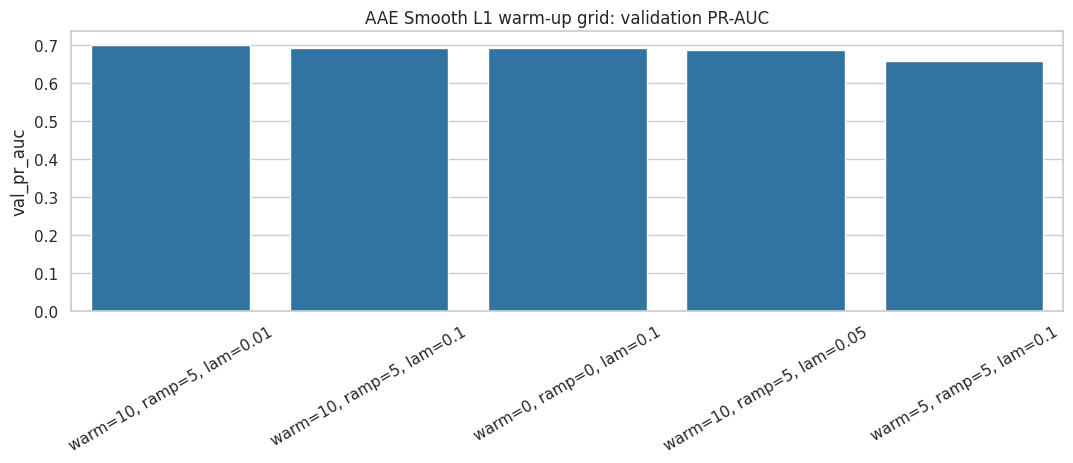

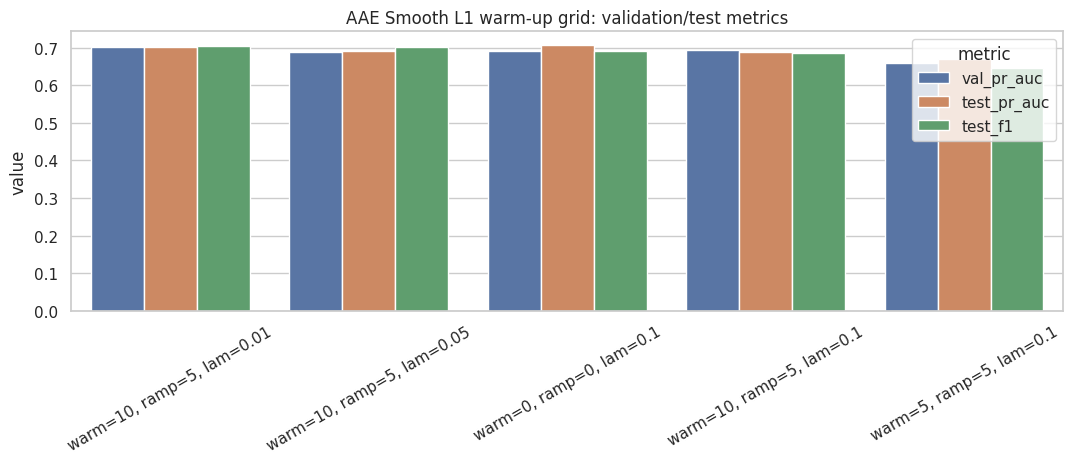

In [7]:
plot_df = warmup_metrics.copy()
plot_df['schedule'] = plot_df.apply(lambda r: f"warm={int(r['warmup_epochs'])}, ramp={int(r['ramp_epochs'])}, lam={r['lambda_adv']:.3g}", axis=1)

plt.figure(figsize=(11, 4.8))
ax = sns.barplot(data=plot_df.sort_values(SELECTION_METRIC, ascending=False), x='schedule', y='val_pr_auc', color='tab:blue')
ax.set_title('AAE Smooth L1 warm-up grid: validation PR-AUC')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
rpt.savefig(FIGURES_DIR / 'warmup_grid_val_pr_auc.png')
plt.show()

plt.figure(figsize=(11, 4.8))
long = plot_df.melt(id_vars='schedule', value_vars=['val_pr_auc', 'test_pr_auc', 'test_f1'], var_name='metric', value_name='value')
ax = sns.barplot(data=long, x='schedule', y='value', hue='metric')
ax.set_title('AAE Smooth L1 warm-up grid: validation/test metrics')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
rpt.savefig(FIGURES_DIR / 'warmup_grid_metrics.png')
plt.show()

## 6. Training dynamics della migliore configurazione

Verifica se il warm-up produce una transizione stabile: lambda effettiva, reconstruction loss, discriminator/adversarial loss e accuratezza del discriminator.

,train_loss,val_loss,discriminator_loss,adversarial_loss,effective_lambda_adv,discriminator_accuracy_real,discriminator_accuracy_fake,mean_d_z_real,mean_d_z_fake,latent_mean_norm,latent_covariance_error,epoch
20,0.1296,0.1172,1.2881,1.1014,0.0100,0.6945,0.5819,0.5854,0.4315,0.9790,2.5995,21
21,0.1266,0.1162,1.2424,0.9846,0.0100,0.6915,0.6036,0.5687,0.4307,1.0404,2.4173,22
22,0.1259,0.1144,1.3100,0.8958,0.0100,0.6405,0.5943,0.5396,0.4462,0.7440,2.2015,23
23,0.1243,0.1139,1.2516,0.8924,0.0100,0.7011,0.6099,0.5589,0.4449,0.6824,2.1752,24
24,0.1230,0.1120,1.2864,0.8813,0.0100,0.6691,0.5978,0.5472,0.4492,0.6776,1.9485,25
25,0.1213,0.1112,1.2991,0.8345,0.0100,0.6734,0.5709,0.5433,0.4602,0.6178,1.8602,26
26,0.1216,0.1116,1.2919,0.8200,0.0100,0.6952,0.5778,0.5466,0.4631,0.5828,1.8271,27
27,0.1209,0.1117,1.2561,0.8528,0.0100,0.6950,0.6278,0.5496,0.4473,0.6170,1.8694,28
28,0.1203,0.1094,1.2633,0.8597,0.0100,0.6816,0.6324,0.5526,0.4489,0.5321,1.8453,29
29,0.1204,0.1091,1.2625,0.8676,0.0100,0.7097,0.6102,0.5512,0.4488,0.6732,1.7839,30


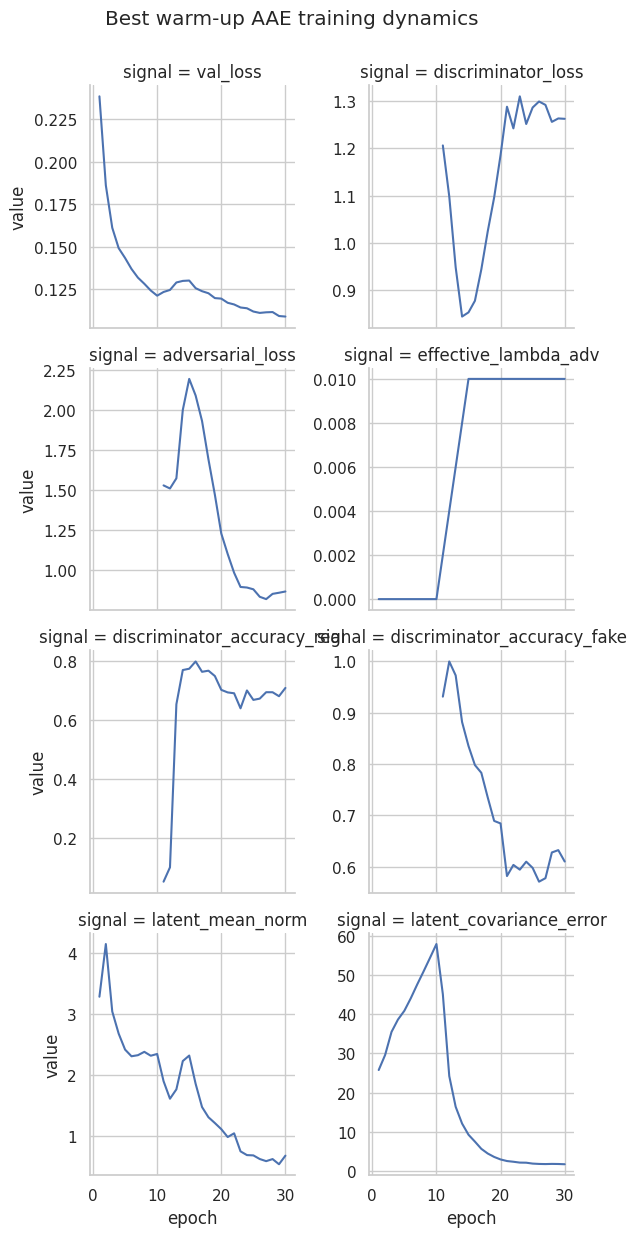

In [8]:
best_run_dir = Path(best_warmup['run_dir'])
history_path = best_run_dir / 'history.json'
with history_path.open('r', encoding='utf-8') as f:
    history = json.load(f)

history_df = pd.DataFrame(history)
history_df['epoch'] = np.arange(1, len(history_df) + 1)
history_df.to_csv(TABLES_DIR / 'best_warmup_history.csv', index=False)
display(history_df.tail(10).style.format(precision=4))

plot_cols = [
    'val_loss',
    'discriminator_loss',
    'adversarial_loss',
    'effective_lambda_adv',
    'discriminator_accuracy_real',
    'discriminator_accuracy_fake',
    'latent_mean_norm',
    'latent_covariance_error',
]
existing = [c for c in plot_cols if c in history_df.columns]
long_hist = history_df.melt(id_vars='epoch', value_vars=existing, var_name='signal', value_name='value')

g = sns.FacetGrid(long_hist, col='signal', col_wrap=2, sharey=False, height=3.0)
g.map_dataframe(sns.lineplot, x='epoch', y='value')
g.fig.suptitle('Best warm-up AAE training dynamics', y=1.03)
g.savefig(FIGURES_DIR / 'best_warmup_training_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Multi-seed confirmation

Conferma minima su seed `[0, 1, 2]`: Isolation Forest, AE Smooth L1, AAE Smooth L1 senza warm-up, AAE Smooth L1 con migliore warm-up.

In [9]:
confirm_root = RUNS_DIR / 'confirmation_multiseed'
seed_args = ' '.join(str(s) for s in CONFIRMATION_SEEDS)
if RUN_CONFIRMATION_MULTI_SEED:
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/isolation_forest.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{confirm_root}" '
        f'--seeds {seed_args} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--skip-existing '
        f'--summary-name if_multiseed.csv'
    )
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/ae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{confirm_root}" '
        f'--seeds {seed_args} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--losses huber '
        f'--skip-existing '
        f'--summary-name ae_smoothl1_multiseed.csv'
    )
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/aae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{confirm_root}" '
        f'--seeds {seed_args} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--losses huber '
        f'--lambda-advs 0.1 '
        f'--warmup-epochs 0 '
        f'--ramp-epochs 0 '
        f'--skip-existing '
        f'--summary-name aae_smoothl1_no_warmup_multiseed.csv'
    )
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/aae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{confirm_root}" '
        f'--seeds {seed_args} '
        f'--window-lengths {PRIMARY_WINDOW_LENGTH} '
        f'--losses huber '
        f'--lambda-advs {BEST_WARMUP["lambda_adv"]} '
        f'--warmup-epochs {BEST_WARMUP["warmup_epochs"]} '
        f'--ramp-epochs {BEST_WARMUP["ramp_epochs"]} '
        f'--skip-existing '
        f'--summary-name aae_smoothl1_best_warmup_multiseed.csv'
    )

confirm_metrics = collect(confirm_root)
confirm_metrics['experiment'] = confirm_metrics.apply(
    lambda r: (
        'Isolation Forest' if r['model_key'] == 'isolation_forest'
        else 'AE Smooth L1' if r['model_key'] == 'ae_mlp'
        else 'AAE Smooth L1 warm-up' if int(r.get('warmup_epochs') or 0) > 0
        else 'AAE Smooth L1 no warm-up'
    ),
    axis=1,
)
confirm_metrics.to_csv(TABLES_DIR / 'confirmation_multiseed_results.csv', index=False)
display(confirm_metrics[['experiment', 'run_name', 'seed', 'lambda_adv', 'warmup_epochs', 'ramp_epochs', 'val_pr_auc', 'test_pr_auc', 'test_f1', 'test_false_alarms_per_run']].sort_values(['experiment', 'seed']).style.format(precision=4))


$ python scripts/run_experiments.py --configs configs/isolation_forest.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/confirmation_multiseed" --seeds 0 1 2 --window-lengths 64 --skip-existing --summary-name if_multiseed.csv

$ python scripts/run_experiments.py --configs configs/ae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/confirmation_multiseed" --seeds 0 1 2 --window-lengths 64 --losses huber --skip-existing --summary-name ae_smoothl1_multiseed.csv

$ python scripts/run_experiments.py --configs configs/aae_mlp.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/warmup_aae_smoothl1/runs/confirmation_multiseed" --seeds 0 1 2 --window-lengths 64 --losses huber --lambda-advs 0.1 --warmup-epochs 0 --ramp-epochs 0 -

,experiment,run_name,seed,lambda_adv,warmup_epochs,ramp_epochs,val_pr_auc,test_pr_auc,test_f1,test_false_alarms_per_run
1,AAE Smooth L1 no warm-up,aae_mlp_seed0_w64_lam0.1_warm0_ramp0_losshuber,0,0.1000,0.0000,0.0000,0.5039,0.6698,0.6658,0.1742
3,AAE Smooth L1 no warm-up,aae_mlp_seed1_w64_lam0.1_warm0_ramp0_losshuber,1,0.1000,0.0000,0.0000,0.6493,0.7057,0.7102,0.1139
5,AAE Smooth L1 no warm-up,aae_mlp_seed2_w64_lam0.1_warm0_ramp0_losshuber,2,0.1000,0.0000,0.0000,0.6399,0.6950,0.6329,0.2262
0,AAE Smooth L1 warm-up,aae_mlp_seed0_w64_lam0.01_warm10_ramp5_losshuber,0,0.0100,10.0000,5.0000,0.4940,0.6801,0.6753,0.1799
2,AAE Smooth L1 warm-up,aae_mlp_seed1_w64_lam0.01_warm10_ramp5_losshuber,1,0.0100,10.0000,5.0000,0.6507,0.7288,0.6675,0.2030
4,AAE Smooth L1 warm-up,aae_mlp_seed2_w64_lam0.01_warm10_ramp5_losshuber,2,0.0100,10.0000,5.0000,0.6392,0.6563,0.6648,0.1483
6,AE Smooth L1,ae_mlp_seed0_w64_losshuber,0,nan,nan,nan,0.5961,0.7136,0.7390,0.1307
7,AE Smooth L1,ae_mlp_seed1_w64_losshuber,1,nan,nan,nan,0.6945,0.8012,0.7642,0.0835
8,AE Smooth L1,ae_mlp_seed2_w64_losshuber,2,nan,nan,nan,0.7281,0.7676,0.7334,0.1103
9,Isolation Forest,isolation_forest_seed0_w64,0,nan,nan,nan,0.6367,0.8270,0.7846,0.1193


## 8. Figure: multi-seed confirmation

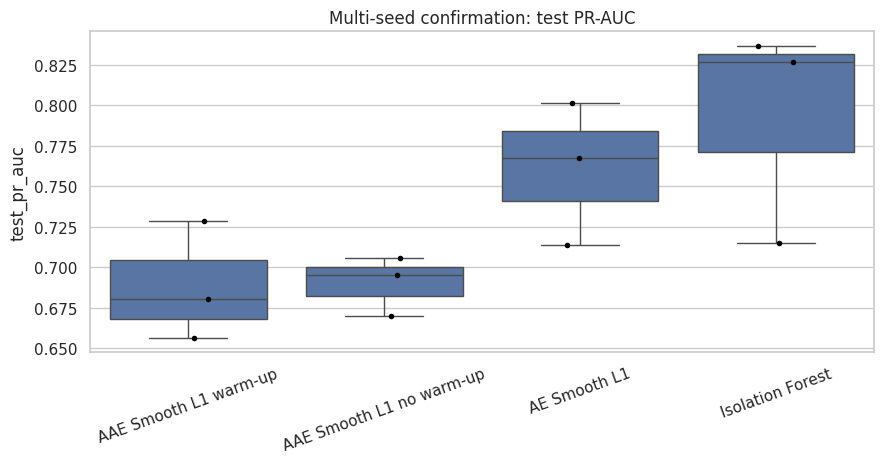

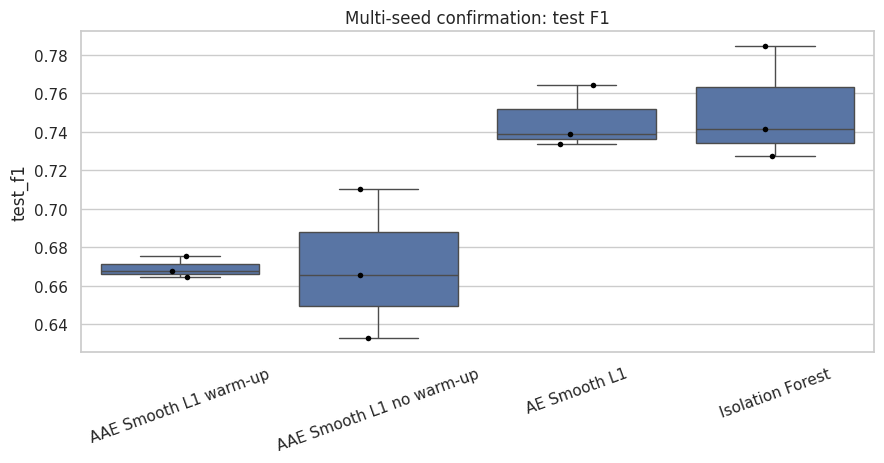

,experiment,mean_test_pr_auc,std_test_pr_auc,mean_test_f1,std_test_f1,mean_false_alarms_per_run
3,Isolation Forest,0.7929,0.0677,0.7511,0.0298,0.1246
2,AE Smooth L1,0.7608,0.0442,0.7455,0.0164,0.1081
0,AAE Smooth L1 no warm-up,0.6902,0.0185,0.6696,0.0388,0.1714
1,AAE Smooth L1 warm-up,0.6884,0.0370,0.6692,0.0054,0.1771


In [10]:
plt.figure(figsize=(9, 4.8))
ax = sns.boxplot(data=confirm_metrics, x='experiment', y='test_pr_auc')
sns.stripplot(data=confirm_metrics, x='experiment', y='test_pr_auc', color='black', size=4, ax=ax)
ax.set_title('Multi-seed confirmation: test PR-AUC')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
rpt.savefig(FIGURES_DIR / 'confirmation_multiseed_test_pr_auc.png')
plt.show()

plt.figure(figsize=(9, 4.8))
ax = sns.boxplot(data=confirm_metrics, x='experiment', y='test_f1')
sns.stripplot(data=confirm_metrics, x='experiment', y='test_f1', color='black', size=4, ax=ax)
ax.set_title('Multi-seed confirmation: test F1')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
rpt.savefig(FIGURES_DIR / 'confirmation_multiseed_test_f1.png')
plt.show()

summary = confirm_metrics.groupby('experiment').agg(
    mean_test_pr_auc=('test_pr_auc', 'mean'),
    std_test_pr_auc=('test_pr_auc', 'std'),
    mean_test_f1=('test_f1', 'mean'),
    std_test_f1=('test_f1', 'std'),
    mean_false_alarms_per_run=('test_false_alarms_per_run', 'mean'),
).reset_index().sort_values('mean_test_pr_auc', ascending=False)
summary.to_csv(TABLES_DIR / 'confirmation_multiseed_summary.csv', index=False)
display(summary.style.format(precision=4))